# Mahalanobis Distance

Detection Method: Statistical

---

## Setup and Data Loading

In [28]:
import mlflow

mlflow.set_tracking_uri("../mlruns_mn/")
mlflow.set_experiment("credit-card-fraud-detection")

<Experiment: artifact_location='file:D:/Projects/creditcard-fraud-detection/notebooks/../mlruns_mn/148532240752397568', creation_time=1776234061153, experiment_id='148532240752397568', last_update_time=1776234061153, lifecycle_stage='active', name='credit-card-fraud-detection', tags={}, trace_location=None, workspace='default'>

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
                             confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

df = pd.read_csv('../data/creditcard.csv')

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

legit_train, legit_test = train_test_split(legit, test_size=0.2, random_state=5)
test_set = pd.concat([legit_test, fraud]).sample(frac=1, random_state=5)


scaler = StandardScaler()
legit_train = legit_train.copy()
test_set = test_set.copy()

legit_train[['Amount', 'Time']] = scaler.fit_transform(legit_train[['Amount', 'Time']])
test_set[['Amount', 'Time']] = scaler.transform(test_set[['Amount', 'Time']])

X_train = legit_train.drop('Class', axis=1).values
X_test = test_set.drop('Class', axis=1).values
y_test = test_set['Class'].values

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape} ")

Training set: (227452, 30)
Test set: (57355, 30) 


---

In [30]:
mlflow.start_run()

<ActiveRun: >

## Overview

Mahalanobis Distance measures the between a transaction and the "normal" distribution. A dataset of legitimate transactions is used to fit a multivariate Gaussian. The distance can be used to detect fraudulent transactions.

## Fit on Legitimate Training Data

In [31]:
X_mean = np.mean(X_train, axis=0)

X_cov = np.cov(X_train.T)
X_cov_inv = np.linalg.pinv(X_cov)

## Score

In [32]:
X_deviation = X_test - X_mean
X_distance = np.sqrt(
    np.einsum("ij,jk,ik->i", X_deviation, X_cov_inv, X_deviation)
)

## Threshold Selection

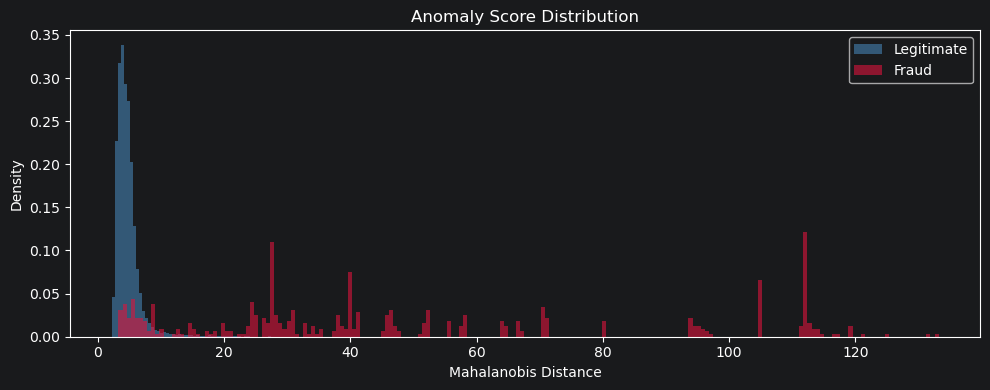

Optimal threshold : 24.0124
Precision         : 0.7178
Recall            : 0.7703
F1                : 0.7431


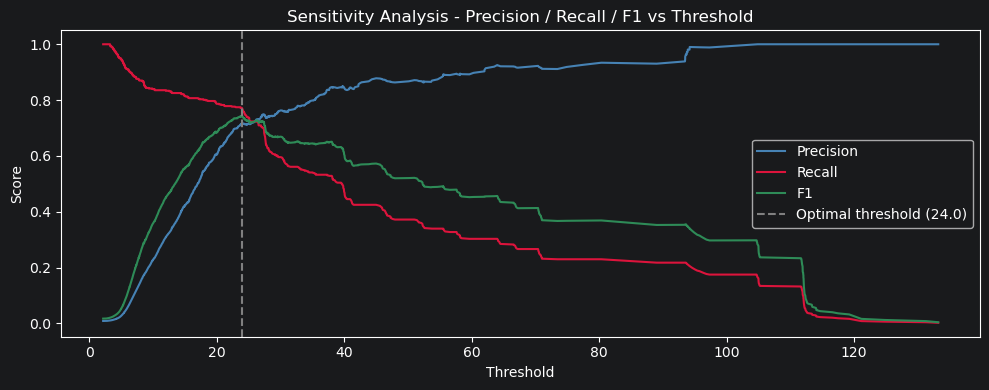

In [33]:
# Score Distribution
fig1, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_distance[y_test == 0], bins=200, alpha=0.6, label='Legitimate', color='steelblue', density=True)
ax.hist(X_distance[y_test == 1], bins=200, alpha=0.6, label='Fraud', color='crimson', density=True)
ax.set_xlabel('Mahalanobis Distance')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig1, "score_distribution.png")
plt.show()

# PR Curve & Optimal Threshold (maximize F1)
precisions, recalls, thresholds = precision_recall_curve(y_test, X_distance)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold : {optimal_threshold:.4f}")
print(f"Precision         : {precisions[:-1][optimal_idx]:.4f}")
print(f"Recall            : {recalls[:-1][optimal_idx]:.4f}")
print(f"F1                : {f1_scores[optimal_idx]:.4f}")

mlflow.log_metrics({
    "Optimal Threshold": optimal_threshold,
    "Precision": precisions[:-1][optimal_idx],
    "Recall": recalls[:-1][optimal_idx],
    "F1": f1_scores[optimal_idx],
})

# Sensitivity Analysis
fig2, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='crimson')
ax.plot(thresholds, f1_scores,       label='F1',        color='seagreen')
ax.axvline(optimal_threshold, color='gray', linestyle='--',
           label=f'Optimal threshold ({optimal_threshold:.1f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity Analysis - Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig2, "sensitivity_analysis.png")
plt.show()

## Evaluation

TN=56714  FP=149  FN=113  TP=379


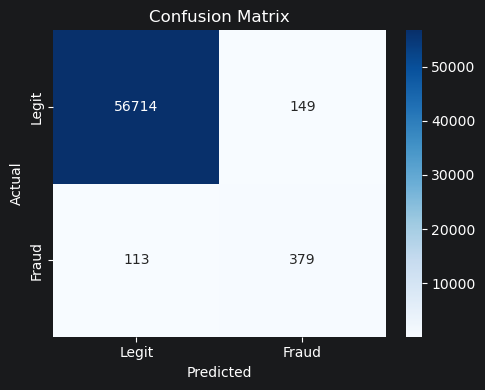

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56863
       Fraud       0.72      0.77      0.74       492

    accuracy                           1.00     57355
   macro avg       0.86      0.88      0.87     57355
weighted avg       1.00      1.00      1.00     57355



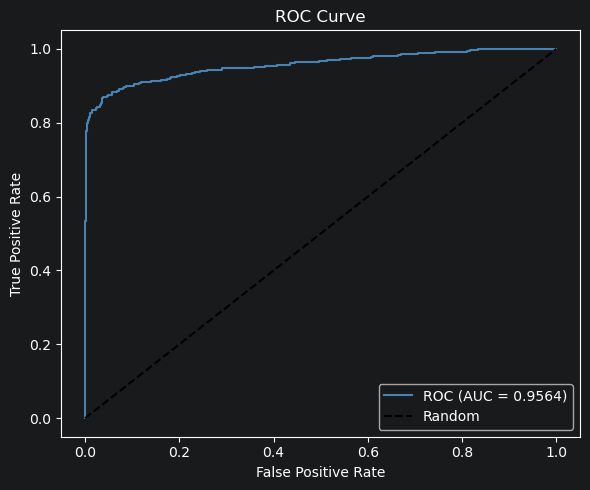

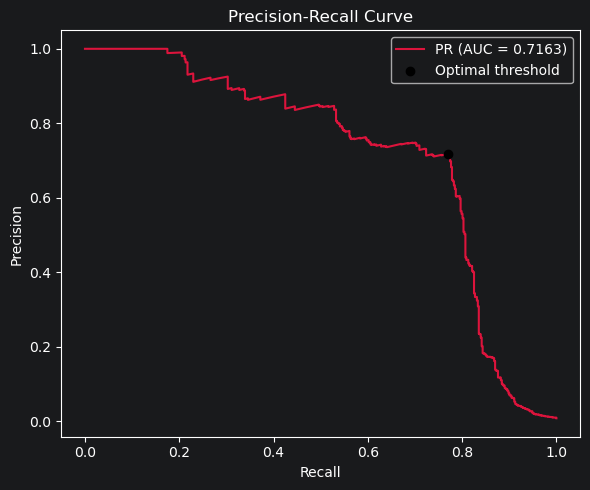

Mean fraud amount : $122.21
Model cost        : $15,299.88
Baseline cost     : $60,127.97
Estimated savings : $44,828.09


In [34]:
y_pred = (X_distance >= optimal_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

fig3, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
mlflow.log_figure(fig3, "confusion_matrix.png")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

# ROC Curve & AUC-ROC
fpr, tpr, _ = roc_curve(y_test, X_distance)
auc_roc = auc(fpr, tpr)
mlflow.log_metric("AUC_ROC", auc_roc)

fig4, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', label=f'ROC (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig4, "roc_curve.png")
plt.show()

# Precision-Recall Curve & AUC-PR
auc_pr = auc(recalls, precisions)
mlflow.log_metric("AUC_PR", auc_pr)

fig5, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, color='crimson', label=f'PR (AUC = {auc_pr:.4f})')
ax.scatter(recalls[:-1][optimal_idx], precisions[:-1][optimal_idx],
           color='black', zorder=5, label='Optimal threshold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig5, "pr_curve.png")
plt.show()

# Business Cost Metric
mean_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
fp_cost = 10           # cost per false alarm (manual review)
fn_cost = mean_fraud_amount  # cost per missed fraud

model_cost    = fp * fp_cost + fn * fn_cost
baseline_cost = len(df[df['Class'] == 1]) * fn_cost  # catch nothing
cost_savings  = baseline_cost - model_cost

print(f"Mean fraud amount : ${mean_fraud_amount:.2f}")
print(f"Model cost        : ${model_cost:,.2f}")
print(f"Baseline cost     : ${baseline_cost:,.2f}")
print(f"Estimated savings : ${cost_savings:,.2f}")

mlflow.log_metrics({
    "cost_model":    model_cost,
    "cost_baseline": baseline_cost,
    "cost_savings":  cost_savings,
})

In [35]:
mlflow.end_run()